In [5]:
import logging
import time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error
from torch.utils.data import DataLoader, TensorDataset
from linear_operator.operators import to_linear_operator

# Assuming these are in a local .utils file as in the original code
from student.constants import EPSILON, JITTER
from student.kernels import rbf_kernel, matern52_kernel
from student.priors import GammaPrior, LogNormalPrior
from student.utils import sample_mvt, kl_mvt_empirical


class SparseXuTPR(nn.Module):
    """
    Sparse Variational Student-t Process Regression (SVTP-MC).
    This implementation follows the Monte Carlo approach for the KL divergence
    as proposed by Xu et al. (2023).
    """
    def __init__(
        self, 
        X, y, M, 
        kernel='rbf',hyper_settings=None, 
        inducing_init_method="kmeans", 
        device=None
    ):
        super().__init__()

        if device is None:
            self.device = X.device if isinstance(X, torch.Tensor) else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)
            
        self.register_buffer('X_full', X.to(self.device))
        self.register_buffer('y_full', y.view(-1, 1).to(self.device))

        if self.X_full.ndim == 1: self.X_full = self.X_full.unsqueeze(1)
        if self.y_full.ndim == 1: self.y_full = self.y_full.unsqueeze(1)

        self.N, self.D = self.X_full.shape
        self.M = M
        dtype = self.X_full.dtype

        # --- Priors for Hyperparameters ---
        self.lengthscale_prior = GammaPrior(2.0, 1.0)
        self.outputscale_prior = GammaPrior(2.0, 1.0)
        self.dof_func_prior = LogNormalPrior(loc=1.0, scale=1.0)
        self.dof_lik_prior = LogNormalPrior(loc=1.0, scale=1.0)
        self.noisescale_prior = LogNormalPrior(loc=-2.0, scale=1.0)

        # --- Initialize Hyperparameters ---
        hyperparameters = self._initialize_hyperparameters(hyper_settings)
        
        # Register hyperparameters as learnable parameters
        self.log_lengthscale = nn.Parameter(torch.log(hyperparameters['lengthscale']))
        self.log_outputscale = nn.Parameter(torch.log(hyperparameters['outputscale']))
        self.log_dof_func = nn.Parameter(torch.log(hyperparameters['dof_func']))
        self.log_dof_lik = nn.Parameter(torch.log(hyperparameters['dof_lik']))
        self.log_noisescale = nn.Parameter(torch.log(hyperparameters['noisescale']))

        # --- Inducing Points ---
        self.Z = nn.Parameter(self._initialize_inducing_points(method=inducing_init_method))

        # --- Variational Parameters for q(u) ---
        self.m_u = nn.Parameter(torch.zeros(self.M, 1, device=self.device, dtype=dtype))
        self.chol_S_u = nn.Parameter(torch.eye(self.M, device=self.device, dtype=dtype))
        self.log_dof_q = nn.Parameter(torch.log(torch.tensor(4.0, device=self.device, dtype=dtype)))

        # Set kernel function
        if kernel in (None, "rbf"): self.kernel = rbf_kernel
        elif kernel == "matern52": self.kernel = matern52_kernel
        else:
            logging.info("Unknown kernel specified. Defaulting to RBF kernel.")
            self.kernel = rbf_kernel

        self.to(self.device)

    def _initialize_inducing_points(self, method="kmeans"):
        if self.N >= self.M:
            if method == "kmeans":
                kmeans = KMeans(n_clusters=self.M, random_state=42, n_init='auto').fit(self.X_full.cpu().numpy())
                Z_init = torch.from_numpy(kmeans.cluster_centers_)
            elif method == "random":
                indices = np.random.choice(self.N, self.M, replace=False)
                Z_init = self.X_full[indices].clone()
            else: raise ValueError(f"Unknown init method: {method}")
        else: # If M > N, just use random points from X with replacement
            indices = np.random.choice(self.N, self.M, replace=True)
            Z_init = self.X_full[indices].clone()
        return Z_init.to(dtype=self.X_full.dtype, device=self.device)

    def _initialize_hyperparameters(self, hyper_settings=None):
        self.hyper_optim_mode = {}
        dtype = self.X_full.dtype
        param_configs = {
            'lengthscale': {'prior': self.lengthscale_prior, 'is_vector': True},
            'outputscale': {'prior': self.outputscale_prior, 'is_vector': False},
            'dof_func': {'prior': self.dof_func_prior, 'is_vector': False},
            'dof_lik': {'prior': self.dof_lik_prior, 'is_vector': False},
            'noisescale': {'prior': self.noisescale_prior, 'is_vector': False}
        }
        initialized_params = {}
        for name, config in param_configs.items():
            settings = (hyper_settings or {}).get(name, {})
            mode = settings.get("optim", "MLE")
            init_val = settings.get("init", None)
            if mode not in ['MLE', 'MAP', 'FIX']: raise ValueError(f"Invalid mode '{mode}' for '{name}'.")
            self.hyper_optim_mode[name] = mode
            if init_val is None:
                sample_shape = (self.D,) if config['is_vector'] else torch.Size([])
                final_value = config['prior'].sample(sample_shape=sample_shape).to(self.device, dtype=dtype)
                if name.startswith('dof'): final_value = final_value.clamp(min=2.0)
                logging.info(f"Sampled initial {name} (Optim mode: {mode}): {final_value.cpu().numpy()}")
            else:
                final_value = torch.as_tensor(init_val, dtype=dtype, device=self.device)
                logging.info(f"Using provided initial {name} (Optim mode: {mode}): {final_value.cpu().numpy()}")
            initialized_params[name] = final_value
        ls = initialized_params['lengthscale']
        if ls.ndim == 0: ls = ls.repeat(self.D)
        initialized_params['lengthscale'] = ls
        return initialized_params

    def _get_hyperparams(self):
        return {
            "lengthscale": torch.exp(self.log_lengthscale).clamp(min=EPSILON),
            "outputscale": torch.exp(self.log_outputscale).clamp(min=EPSILON),
            "dof_func": torch.exp(self.log_dof_func).clamp(min=EPSILON),
            "dof_lik": torch.exp(self.log_dof_lik).clamp(min=EPSILON),
            "noisescale": torch.exp(self.log_noisescale).clamp(min=EPSILON),
            "dof_q": torch.exp(self.log_dof_q).clamp(min=EPSILON),
        }

    def _calculate_log_prior(self, params):
        log_prior = torch.tensor(0.0, device=self.device, dtype=params['lengthscale'].dtype)
        if self.hyper_optim_mode['lengthscale'] == 'MAP': log_prior += self.lengthscale_prior.log_prob(params['lengthscale']).sum()
        if self.hyper_optim_mode['outputscale'] == 'MAP': log_prior += self.outputscale_prior.log_prob(params['outputscale'])
        if self.hyper_optim_mode['dof_func'] == 'MAP': log_prior += self.dof_func_prior.log_prob(params['dof_func'])
        if self.hyper_optim_mode['dof_lik'] == 'MAP': log_prior += self.dof_lik_prior.log_prob(params['dof_lik'])
        if self.hyper_optim_mode['noisescale'] == 'MAP': log_prior += self.noisescale_prior.log_prob(params['noisescale'])
        return log_prior

    def calculate_elbo(self, X_batch, y_batch, num_samples=100):
        params = self._get_hyperparams()
        batch_size = X_batch.shape[0]

        # --- 1. Compute Expected Log-Likelihood ---
        # Sample u from q(u) ~ ST(m_u, S_u, dof_q)
        scale_tril_q = torch.tril(self.chol_S_u)
        u_samples = sample_mvt(self.m_u, scale_tril_q, params['dof_q'], num_samples) # [M, 1, num_samples]

        # Compute kernels
        K_ZZ_base = self.kernel(self.Z, self.Z, params['lengthscale'], params['outputscale'])
        K_ZZ_op = to_linear_operator(K_ZZ_base).add_jitter(JITTER)
        K_XZ_batch = self.kernel(X_batch, self.Z, params['lengthscale'], params['outputscale'])
        K_XX_batch_diag = self.kernel(X_batch, X_batch, params['lengthscale'], params['outputscale']).diag()

        # Get parameters for p(f|u) for each u_sample
        K_ZZ_inv_u = K_ZZ_op.solve(u_samples.squeeze(1)) # [M, num_samples]
        mu_f_cond = K_XZ_batch @ K_ZZ_inv_u # [batch_size, num_samples]

        beta = (u_samples.squeeze(1) * K_ZZ_inv_u).sum(0) # [num_samples]
        dof_f_cond = params['dof_func'] + self.M

        K_XZ_K_inv = K_ZZ_op.solve(K_XZ_batch.T).T
        term2 = (K_XZ_K_inv * K_XZ_batch).sum(1) # [batch_size]
        scale_base = K_XX_batch_diag - term2 # [batch_size]

        scale_factor = (params['dof_func'] + beta) / dof_f_cond # [num_samples]
        scale_f_cond_sq = scale_base.unsqueeze(1) * scale_factor.unsqueeze(0) # [batch_size, num_samples]

        # We now have the parameters for p(f|u). We can compute p(y|f) using these.
        # This gives us a distribution over y for each u_sample.
        lik_dist = torch.distributions.StudentT(
            df=params['dof_lik'],
            loc=mu_f_cond,
            scale=torch.sqrt(scale_f_cond_sq.clamp(min=EPSILON) + params['noisescale'].pow(2))
        )
        
        # Average over MC samples
        expected_log_lik = lik_dist.log_prob(y_batch).sum(0).mean()
        
        # Scale for full dataset size
        scaled_log_lik = expected_log_lik * (self.N / batch_size)

        # --- 2. Compute KL Divergence KL(q(u)||p(u)) ---
        K_ZZ_chol = K_ZZ_op.cholesky()
        kl_div = kl_mvt_empirical(
            mu_q=self.m_u,
            scale_tril_q=scale_tril_q,
            dof_q=params['dof_q'],
            mu_p=torch.zeros_like(self.m_u),
            scale_tril_p=K_ZZ_chol,
            dof_p=params['dof_func'],
            num_samples=num_samples
        )
        
        return scaled_log_lik - kl_div

    def fit(
        self, 
        epochs=200, batch_size=128, 
        lr=0.01, num_samples=100, 
        X_test=None, y_test=None, eval_interval=10
    ):
        params_to_optimize = []
        for name, p in self.named_parameters():
            if name in ['m_u', 'chol_S_u', 'log_dof_q', 'Z']:
                params_to_optimize.append(p)
            elif self.hyper_optim_mode.get(name.replace("log_", ""), "MLE") != 'FIX':
                params_to_optimize.append(p)

        optimizer = optim.Adam(params_to_optimize, lr=lr) if params_to_optimize else None
        dataset = TensorDataset(self.X_full, self.y_full)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        history = {
            'elbo': [], 'log_prior': [], 'loss': [], 
            'eval_epochs': [], 'eval_metrics': [], 'fit_times': []
        }
        logging.info(f"Starting SVI training for {epochs} epochs...")

        for epoch in range(epochs):
            epoch_loss = 0.0
            for X_batch, y_batch in dataloader:

                fit_start_time = time.time()

                optimizer.zero_grad()
                
                elbo = self.calculate_elbo(X_batch, y_batch, num_samples=num_samples)
                log_prior = self._calculate_log_prior(self._get_hyperparams())
                loss = -(elbo + log_prior)
                
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()

                fit_end_time = time.time()
                history['fit_times'].append(fit_end_time - fit_start_time)

                history['loss'].append(loss)
                history['elbo'].append(elbo.item()) 
                history['log_prior'].append(log_prior.item()) 
            
            if (epoch + 1) % eval_interval == 0:
                logging.info(f"Epoch {epoch+1:4d}/{epochs} | Loss: {loss:.3f} | ELBO: {elbo.item():.3f}")

            if X_test is not None and y_test is not None and (epoch + 1) % eval_interval == 0:
                metrics = self._evaluate(X_test, y_test, num_samples=num_samples)
                history['eval_epochs'].append(epoch + 1)
                history['eval_metrics'].append(metrics)
                logging.info(f"Epoch {epoch+1:4d} | Test RMSE: {metrics['rmse']:.4f}")

        logging.info("Training finished.")
        return history

    def predict(self, X_test, num_samples=1000):
        self.eval()
        X_test = torch.as_tensor(X_test, dtype=self.X_full.dtype, device=self.device)
        if X_test.ndim == 1: X_test = X_test.unsqueeze(1)
        
        with torch.no_grad():
            params = self._get_hyperparams()
            
            # 1. Sample u from the variational posterior q(u)
            u_samples = sample_mvt(self.m_u, self.chol_S_u, params['dof_q'], num_samples) # [M, 1, num_samples]

            # 2. Compute kernels
            K_ZZ_base = self.kernel(self.Z, self.Z, params['lengthscale'], params['outputscale'])
            K_ZZ_op = to_linear_operator(K_ZZ_base).add_jitter(JITTER)
            K_star_Z = self.kernel(X_test, self.Z, params['lengthscale'], params['outputscale'])
            k_star_star_diag = self.kernel(X_test, X_test, params['lengthscale'], params['outputscale']).diag()
            
            # 3. For each u_sample, find the parameters of p(f*|u)
            K_ZZ_inv_u = K_ZZ_op.solve(u_samples.squeeze(1)) # [M, num_samples]
            predictive_loc_per_sample = K_star_Z @ K_ZZ_inv_u # [N_test, num_samples]
            
            beta_per_sample = (u_samples.squeeze(1) * K_ZZ_inv_u).sum(0) # [num_samples]
            dof_pred = params['dof_func'] + self.M
            
            K_star_Z_K_inv = K_ZZ_op.solve(K_star_Z.T).T
            term2 = (K_star_Z_K_inv * K_star_Z).sum(1) # [N_test]
            scale_base = k_star_star_diag - term2 # [N_test]
            
            scale_factor = (params['dof_func'] + beta_per_sample) / dof_pred # [num_samples]
            predictive_scale_sq_per_sample = scale_base.unsqueeze(1) * scale_factor.unsqueeze(0) # [N_test, num_samples]
            
            # 4. Sample f* from p(f*|u) for each u_sample
            pred_dist = torch.distributions.StudentT(
                df=dof_pred,
                loc=predictive_loc_per_sample,
                scale=torch.sqrt(predictive_scale_sq_per_sample.clamp(min=EPSILON))
            )
            predictive_f_star_samples = pred_dist.sample()

            # # 5. (Optional) Sample y* from p(y*|f*) to include observation noise
            # noise_dist = torch.distributions.StudentT(
            #     df=params['dof_lik'],
            #     loc=predictive_f_star_samples,
            #     scale=params['noisescale']
            # )
            # predictive_y_star_samples = noise_dist.sample()
            
        self.train()
        return predictive_f_star_samples.cpu().numpy()

    def _evaluate(self, X_test, y_test, num_samples):
        predictive_samples = self.predict(X_test, num_samples=num_samples)
        mu_pred = np.mean(predictive_samples, axis=1)
        y_true = y_test.cpu().numpy().squeeze()
        rmse = np.sqrt(mean_squared_error(y_true, mu_pred))
        return {'rmse': rmse}

2025-09-14 23:04:32,511 - INFO - Using device: cuda
2025-09-14 23:04:32,529 - INFO - Sampled initial lengthscale (Optim mode: MAP): [2.25804412]
2025-09-14 23:04:32,530 - INFO - Using provided initial outputscale (Optim mode: FIX): 1.0
2025-09-14 23:04:32,531 - INFO - Sampled initial dof_func (Optim mode: MLE): 3.208069461057689
2025-09-14 23:04:32,532 - INFO - Sampled initial dof_lik (Optim mode: MLE): 3.2370921165718225
2025-09-14 23:04:32,533 - INFO - Sampled initial noisescale (Optim mode: MAP): 0.2256038759788275
2025-09-14 23:04:32,539 - INFO - Starting SVI training for 300 epochs...
2025-09-14 23:04:33,640 - INFO - Epoch   20/300 | Loss: 257.823 | ELBO: -256.591
2025-09-14 23:04:33,644 - INFO - Epoch   20 | Test RMSE: 1.0167
2025-09-14 23:04:34,689 - INFO - Epoch   40/300 | Loss: 123.120 | ELBO: -122.119
2025-09-14 23:04:34,693 - INFO - Epoch   40 | Test RMSE: 0.9700
2025-09-14 23:04:35,726 - INFO - Epoch   60/300 | Loss: 218.481 | ELBO: -217.767
2025-09-14 23:04:35,730 - INFO -

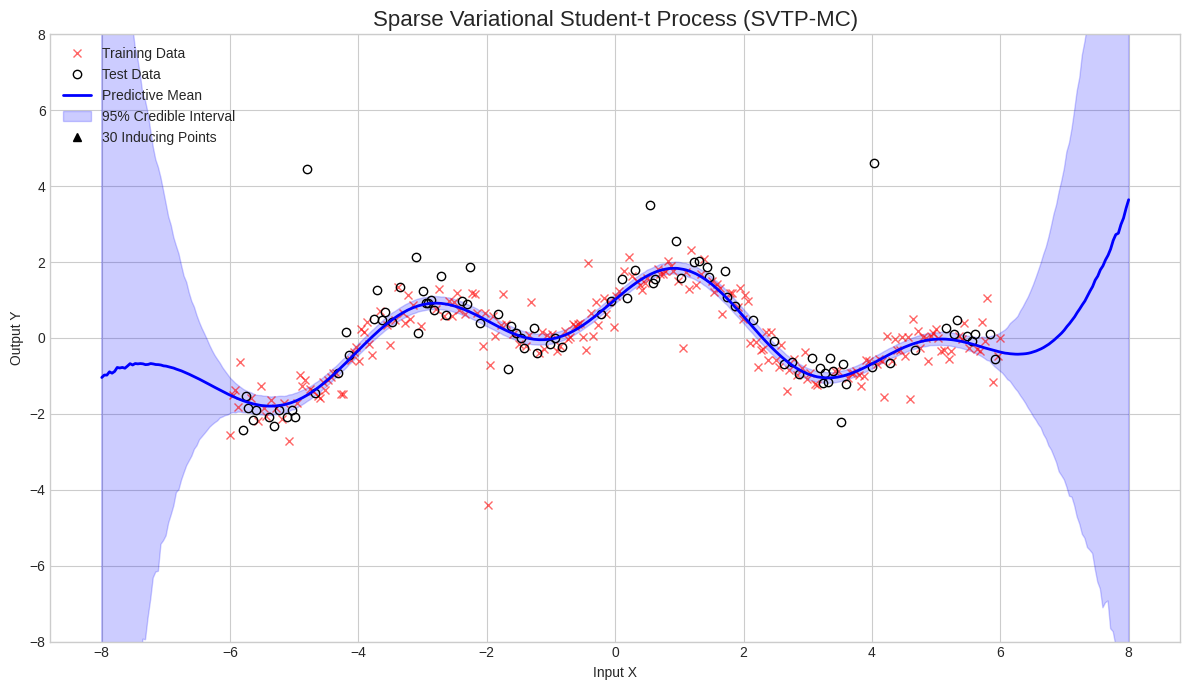

In [6]:

if __name__ == '__main__':
    from sklearn.model_selection import train_test_split
    import matplotlib.pyplot as plt

    # --- Configure logging ---
    logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

    # --- Generate Synthetic Data ---
    torch.manual_seed(43); np.random.seed(43)
    N_data = 300
    X_data = torch.linspace(-6, 6, N_data).unsqueeze(1)
    
    # True underlying function
    y_true = torch.sin(X_data * 1.5) + torch.cos(X_data * 0.5)
    
    # Add heavy-tailed Student-t noise
    t_dist = torch.distributions.StudentT(df=3.0)
    noise = t_dist.sample(X_data.shape) * 0.3
    y_data = y_true + noise
    
    # Inject some large outliers
    outlier_indices = [30, 100, 250]
    y_data[outlier_indices] += torch.tensor([[6.0], [-5.0], [5.5]])

    # Split into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.3, random_state=42
    )

    # --- Initialize and Train the Model ---
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    logging.info(f"Using device: {device}")
    
    # Example hyperparameter settings:
    # - MAP for lengthscale and noise (regularized by prior)
    # - Fix outputscale to 1.0 (common practice)
    # - MLE for everything else (optimized without prior influence)
    hyper_settings = {
        'lengthscale': {'optim': 'MAP'},
        'outputscale': {'optim': 'FIX', 'init': 1.0},
        'noisescale':  {'optim': 'MAP'},
    }

    # Number of inducing points
    M = 30 
    
    model = SparseXuTPR(
        X_train, y_train, M=M, 
        hyper_settings=hyper_settings, device=device
    )
    
    history = model.fit(
        epochs=300, 
        lr=0.01, 
        batch_size=64,
        num_samples=100, # Number of samples for ELBO and KL estimation
        X_test=X_test, 
        y_test=y_test, 
        eval_interval=20
    )
    
    # --- Make Final Predictions for Plotting ---
    X_plot = torch.linspace(-8, 8, 400).unsqueeze(1)
    predictive_samples = model.predict(X_plot, num_samples=2000)
    
    # Calculate predictive mean and 95% credible interval
    mu_pred = np.mean(predictive_samples, axis=1)
    lower_ci, upper_ci = np.quantile(predictive_samples, [0.025, 0.975], axis=1)
    
    # --- Visualize the Results ---
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(12, 7))
    
    # Plot data
    plt.plot(X_train.cpu(), y_train.cpu(), 'rx', label='Training Data', alpha=0.6)
    plt.plot(X_test.cpu(), y_test.cpu(), 'ko', mfc='none', label='Test Data')
    
    # Plot model prediction
    plt.plot(X_plot.cpu(), mu_pred, 'b-', lw=2, label='Predictive Mean')
    plt.fill_between(
        X_plot.squeeze().cpu(), lower_ci, upper_ci, 
        color='blue', alpha=0.2, label='95% Credible Interval'
    )
    
    # Plot inducing points
    inducing_points = model.Z.detach().cpu().numpy()
    plt.plot(inducing_points, np.ones_like(inducing_points) * plt.ylim()[0], 'k^', label=f'{M} Inducing Points')
    
    plt.title('Sparse Variational Student-t Process (SVTP-MC)', fontsize=16)
    plt.xlabel('Input X')
    plt.ylabel('Output Y')
    plt.legend(loc='upper left')
    plt.ylim(-8, 8)
    plt.tight_layout()
    plt.show()